# Week 10 — Neural Networks & Deep Learning for Forecasting

This final notebook introduces neural networks for time-series prediction: feedforward networks, recurrent neural networks (RNNs), and LSTMs — the frontier of forecasting methodology.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 10.1 From Linear Models to Neural Networks

A feedforward neural network with one hidden layer:

$$\hat{y} = W_2 \cdot \sigma(W_1 x + b_1) + b_2$$

where $\sigma$ is an activation function (ReLU, sigmoid, tanh).

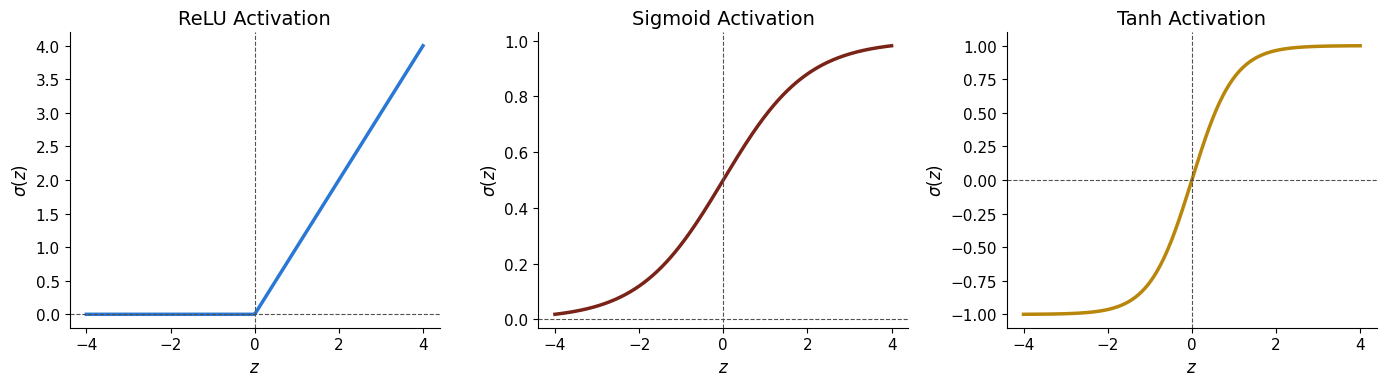

In [2]:
# Activation functions
x = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
activations = [
    ('ReLU', np.maximum(0, x), UOE_BLUE),
    ('Sigmoid', 1 / (1 + np.exp(-x)), UOE_RED),
    ('Tanh', np.tanh(x), UOE_GOLD),
]

for ax, (name, y_act, col) in zip(axes, activations):
    ax.plot(x, y_act, color=col, lw=2.5)
    ax.axhline(0, ls='--', color=UOE_GREY, lw=0.8)
    ax.axvline(0, ls='--', color=UOE_GREY, lw=0.8)
    ax.set_title(f'{name} Activation')
    ax.set_xlabel('$z$')
    ax.set_ylabel(f'$\\sigma(z)$')

plt.tight_layout()
plt.show()


## 10.2 Universal Approximation

Neural networks with a single hidden layer can approximate any continuous function. Let's see this in action — fitting a nonlinear relationship.

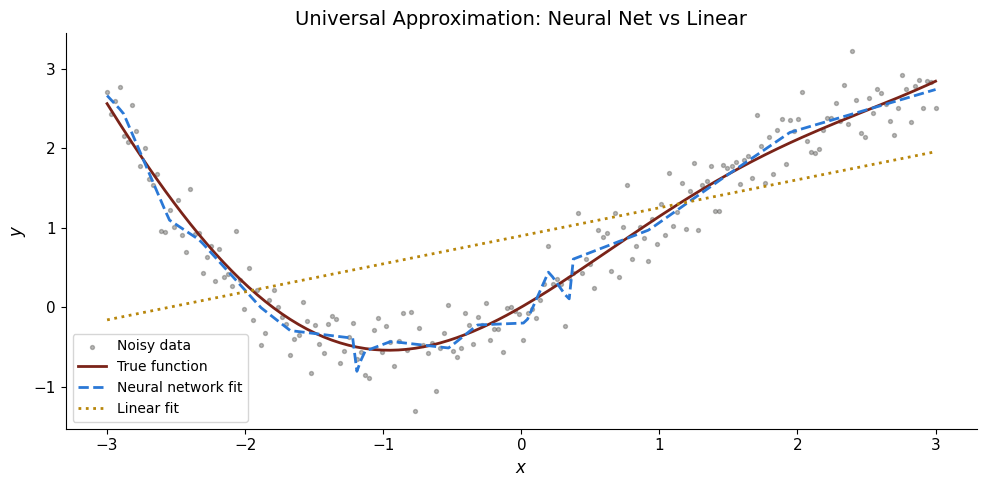

In [3]:
# Neural network vs linear: approximating a nonlinear function
np.random.seed(42)
x_data = np.linspace(-3, 3, 200)
y_true = np.sin(x_data) + 0.3 * x_data**2
y_noisy = y_true + np.random.normal(0, 0.3, 200)

# Simple 1-hidden-layer network (manual numpy implementation)
def relu(z):
    return np.maximum(0, z)

# Train a small network with random search (illustrative)
best_loss = np.inf
best_pred = None
n_hidden = 20

for trial in range(5000):
    W1 = np.random.randn(1, n_hidden) * 0.5
    b1 = np.random.randn(n_hidden) * 0.5
    hidden = relu(x_data.reshape(-1, 1) @ W1 + b1)
    # Solve for W2 via least squares
    W2 = np.linalg.lstsq(hidden, y_noisy, rcond=None)[0]
    pred = hidden @ W2
    loss = np.mean((y_noisy - pred)**2)
    if loss < best_loss:
        best_loss = loss
        best_pred = pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_data, y_noisy, s=8, alpha=0.4, color=UOE_GREY, label='Noisy data')
ax.plot(x_data, y_true, color=UOE_RED, lw=2, label='True function')
ax.plot(x_data, best_pred, '--', color=UOE_BLUE, lw=2, label='Neural network fit')
# Linear fit
p = np.polyfit(x_data, y_noisy, 1)
ax.plot(x_data, np.polyval(p, x_data), ':', color=UOE_GOLD, lw=2, label='Linear fit')
ax.set_title('Universal Approximation: Neural Net vs Linear')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.legend()
plt.tight_layout()
plt.show()


## 10.3 Feedforward Network for Time Series

We can use lagged values as features and train a neural network to forecast.

I0000 00:00:1786350683.666990    5439 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786350683.667999    5439 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786350683.729615    5439 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786350685.805724    5439 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786350685.806251    5439 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1786350687.434860    5439 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


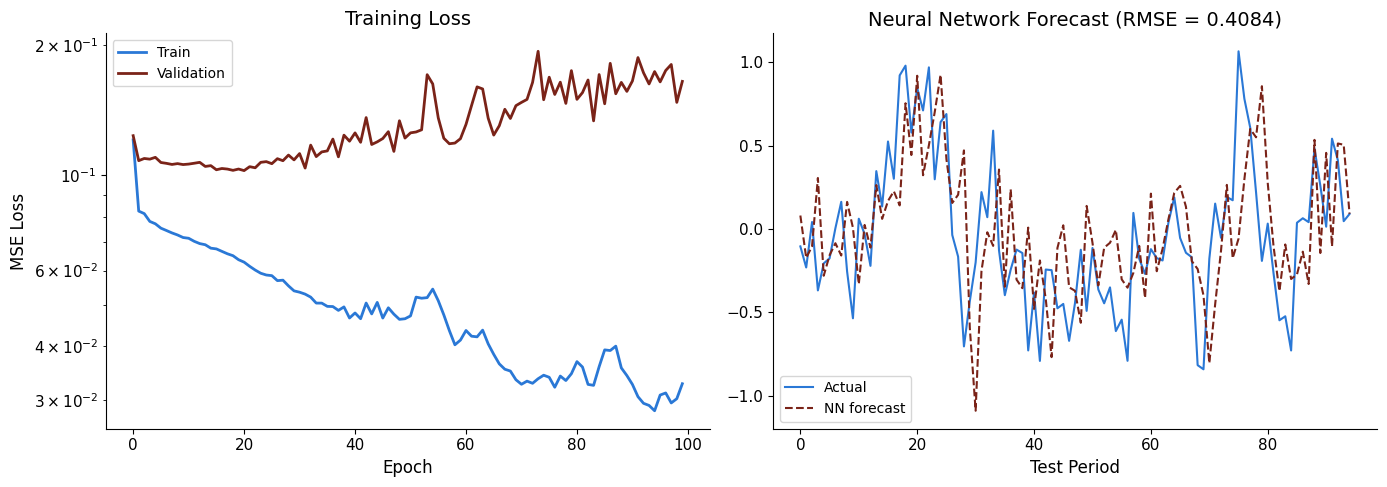

In [4]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

# Generate nonlinear AR data
np.random.seed(42)
T = 500
y_nl = np.zeros(T)
for t in range(2, T):
    y_nl[t] = 0.5 * np.tanh(y_nl[t-1]) + 0.3 * y_nl[t-2] + np.random.normal(0, 0.3)

# Prepare data with 5 lags
n_lags = 5
X_nn = np.column_stack([y_nl[n_lags-1-j:T-1-j] for j in range(n_lags)])
y_nn = y_nl[n_lags:]

split = 400
X_tr, X_te = X_nn[:split], X_nn[split:]
y_tr, y_te = y_nn[:split], y_nn[split:]

# Simple feedforward network
model_nn = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(n_lags,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])
model_nn.compile(optimizer=keras.optimizers.Adam(0.01), loss='mse')
history = model_nn.fit(X_tr, y_tr, epochs=100, batch_size=32, verbose=0,
                       validation_split=0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], color=UOE_BLUE, label='Train')
ax1.plot(history.history['val_loss'], color=UOE_RED, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss')
ax1.set_yscale('log')
ax1.legend()

nn_pred = model_nn.predict(X_te, verbose=0).flatten()

ax2.plot(y_te, color=UOE_BLUE, lw=1.5, label='Actual')
ax2.plot(nn_pred, '--', color=UOE_RED, lw=1.5, label='NN forecast')
ax2.set_title(f'Neural Network Forecast (RMSE = {np.sqrt(np.mean((y_te - nn_pred)**2)):.4f})')
ax2.set_xlabel('Test Period')
ax2.legend()

plt.tight_layout()
plt.show()


## 10.4 Recurrent Neural Networks (RNNs) and LSTMs

RNNs process sequences by maintaining a hidden state:

$$h_t = \sigma(W_h h_{t-1} + W_x x_t + b)$$

LSTMs add gating mechanisms to handle long-range dependencies.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


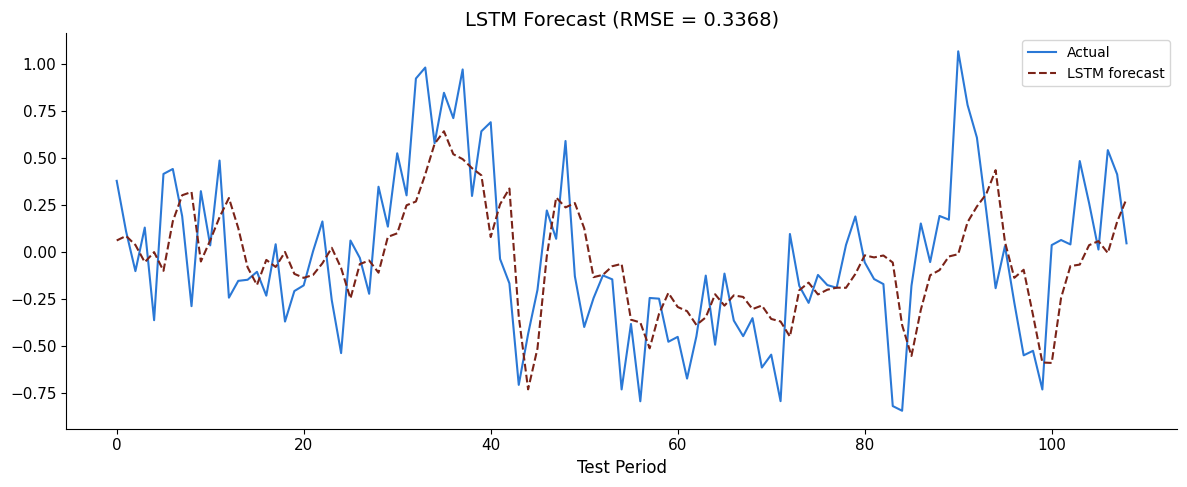

In [5]:
# LSTM for time-series forecasting
seq_len = 10
X_seq, y_seq = [], []
for t in range(seq_len, len(y_nl) - 1):
    X_seq.append(y_nl[t-seq_len:t])
    y_seq.append(y_nl[t])

X_seq = np.array(X_seq).reshape(-1, seq_len, 1)  # (N, seq_len, 1)
y_seq = np.array(y_seq)

split_s = 380
X_tr_s, X_te_s = X_seq[:split_s], X_seq[split_s:]
y_tr_s, y_te_s = y_seq[:split_s], y_seq[split_s:]

# Build LSTM model
lstm = keras.Sequential([
    keras.layers.LSTM(32, input_shape=(seq_len, 1)),
    keras.layers.Dense(1)
])
lstm.compile(optimizer=keras.optimizers.Adam(0.005), loss='mse')
lstm.fit(X_tr_s, y_tr_s, epochs=50, batch_size=32, verbose=0)

lstm_pred = lstm.predict(X_te_s, verbose=0).flatten()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te_s, color=UOE_BLUE, lw=1.5, label='Actual')
ax.plot(lstm_pred, '--', color=UOE_RED, lw=1.5, label='LSTM forecast')
ax.set_title(f'LSTM Forecast (RMSE = {np.sqrt(np.mean((y_te_s - lstm_pred)**2)):.4f})')
ax.set_xlabel('Test Period')
ax.legend()
plt.tight_layout()
plt.show()


## 10.5 Model Comparison Summary

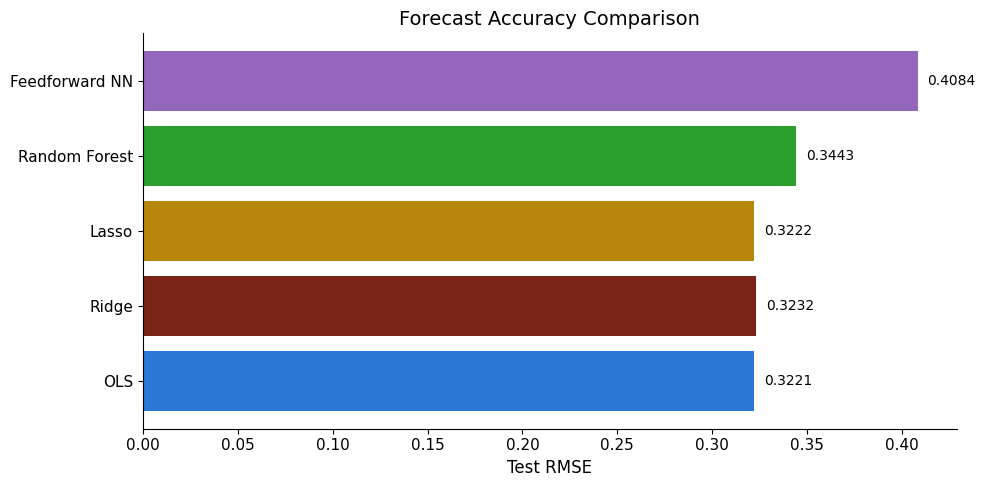

In [6]:
# Summary comparison
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor

X_all = np.column_stack([y_nl[n_lags-1-j:T-1-j] for j in range(n_lags)])
y_all = y_nl[n_lags:]
Xtr, Xte = X_all[:split], X_all[split:]
ytr, yte = y_all[:split], y_all[split:]

methods = {}

# OLS
lr = LinearRegression().fit(Xtr, ytr)
methods['OLS'] = np.sqrt(np.mean((yte - lr.predict(Xte))**2))

# Ridge
ridge = RidgeCV(alphas=np.logspace(-3, 2, 50)).fit(Xtr, ytr)
methods['Ridge'] = np.sqrt(np.mean((yte - ridge.predict(Xte))**2))

# Lasso
lasso = LassoCV(max_iter=10000).fit(Xtr, ytr)
methods['Lasso'] = np.sqrt(np.mean((yte - lasso.predict(Xte))**2))

# Random Forest
rf2 = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(Xtr, ytr)
methods['Random Forest'] = np.sqrt(np.mean((yte - rf2.predict(Xte))**2))

# Neural Net (already computed above)
methods['Feedforward NN'] = np.sqrt(np.mean((y_te - nn_pred)**2))

fig, ax = plt.subplots(figsize=(10, 5))
names = list(methods.keys())
rmses = list(methods.values())
bars = ax.barh(names, rmses, color=[UOE_BLUE, UOE_RED, UOE_GOLD, '#2ca02c', '#9467bd'])
ax.set_xlabel('Test RMSE')
ax.set_title('Forecast Accuracy Comparison')
for bar, v in zip(bars, rmses):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


## 10.6 When to Use What?

| Method | Strengths | Weaknesses |
|:-------|:----------|:-----------|
| ARMA | Interpretable, theory-grounded | Linear, low-dimensional |
| Exponential Smoothing | Handles trend + seasonality | Univariate only |
| VAR | Multivariate dynamics, IRFs | Many parameters |
| State Space | Flexible, handles missing data | Model specification |
| Ridge/Lasso | Handles many predictors | Still linear |
| Random Forest | Nonlinear, automatic | No uncertainty quantification |
| Neural Networks | Universal approximation | Needs lots of data, opaque |

## Exercises

<details><summary>Exercise 1: Add dropout regularisation to the feedforward network and compare.</summary>

```python
model_reg = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(5,)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
])
model_reg.compile(optimizer='adam', loss='mse')
```
</details>